In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pyarrow

# configurar o notebook para exibir todas as colunas
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_pickle('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/df_renamed.pkl')

In [2]:
df.columns

Index(['target', 'acct_bal', 'dur_months', 'cred_hist', 'purpose', 'cred_amt',
       'savings', 'emp_dur', 'inst_rate', 'pers_status', 'guarantors',
       'res_dur', 'property', 'age', 'other_creds', 'housing', 'num_creds',
       'job', 'dependents', 'phone', 'foreign_worker'],
      dtype='object')

In [3]:
numerical_cols      = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
continuos_cols      = [col for col in numerical_cols if df[col].nunique() > 10]
discrete_cols       = [col for col in numerical_cols if df[col].nunique() <= 10]
categorical_cols    = df.select_dtypes(include=['category', 'object']).columns.tolist()

DISTRIBUIÇÃO VARIAVEIS CONTINUAS

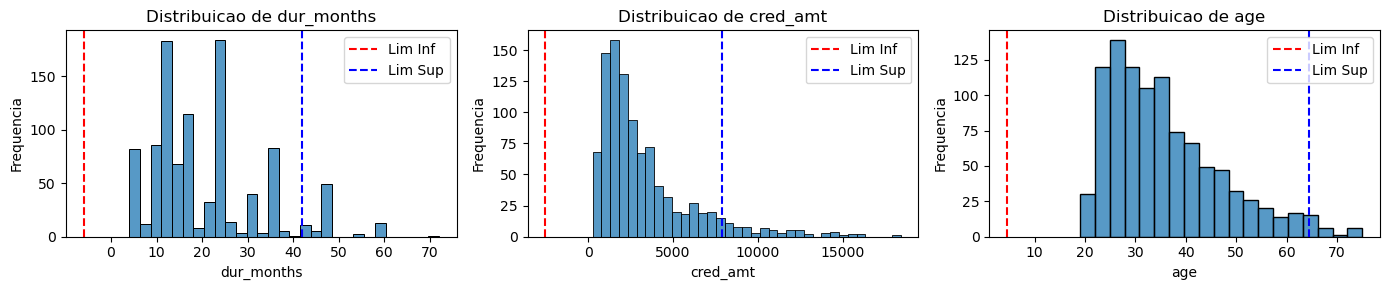

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 3
n_rows = int(np.ceil(len(continuos_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))

for idx, col in enumerate(continuos_cols):
    q25, q75 = np.percentile(df[col], 25), np.percentile(df[col], 75)
    iqr = q75 - q25
    cutt_off = 1.5 * iqr
    lower_bound = q25 - cutt_off
    upper_bound = q75 + cutt_off
    
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]
    sns.histplot(df[col], ax=ax)
    ax.set_title(f'Distribuicao de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequencia')

    # limites de outlier
    ax.axvline(lower_bound, color='red', linestyle='--', label='Lim Inf')
    ax.axvline(upper_bound, color='blue', linestyle='--', label='Lim Sup')
    ax.legend()

# Remove empty subplots if any
for idx in range(len(numerical_cols), n_rows * n_cols):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()

In [4]:
# variavel df.dur_months principais estatisticas
for col in continuos_cols:
    print(df[col].describe().to_frame().T)
    print('\n')


             count    mean        std  min   25%   50%   75%   max
dur_months  1000.0  20.903  12.058814  4.0  12.0  18.0  24.0  72.0


           count      mean         std    min     25%     50%      75%  \
cred_amt  1000.0  3271.248  2822.75176  250.0  1365.5  2319.5  3972.25   

              max  
cred_amt  18424.0  


      count    mean       std   min   25%   50%   75%   max
age  1000.0  35.542  11.35267  19.0  27.0  33.0  42.0  75.0




DISTRIBUIÇÃO VARIAVEIS DISCRETAS

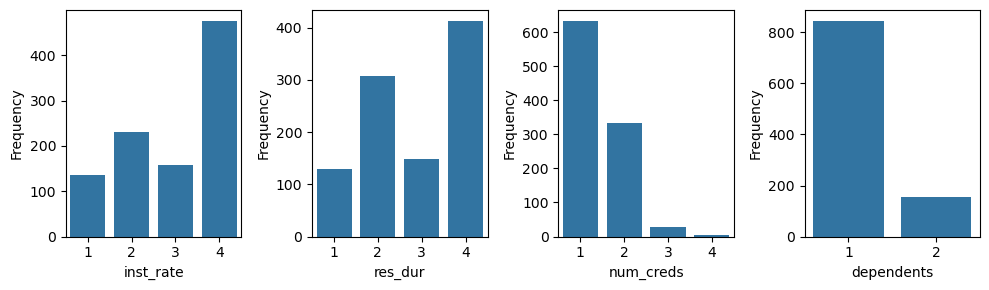

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 4
n_rows = int(np.ceil(len(discrete_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3 * n_rows))

for idx, col in enumerate(discrete_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]
    sns.countplot(x=df[col], ax=ax)
    #ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

# Remove empty subplots if any
for idx in range(len(discrete_cols), n_rows * n_cols):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()

IDENTIFICACAO DE VARIAVEIS COM POUCOS VALORES

In [3]:
for i in df.columns[1:].tolist():
    num = len(df.loc[:, i].unique())
    percentage = float(num) / df.shape[0] * 100
    #if percentage < 1:                             # ajustar o valor de corte
    print('%s, %d, %.1f%%' % (i, num, percentage))

counts2 = df[numerical_cols].nunique()
to_del2 = [col for col in df[numerical_cols].columns if (float(counts2[col])/df.shape[0]*100) < 1]
print()
print(f"Para deletar (under 1%): {to_del2}")


acct_bal, 4, 0.4%
dur_months, 33, 3.3%
cred_hist, 5, 0.5%
purpose, 10, 1.0%
cred_amt, 923, 92.3%
savings, 5, 0.5%
emp_dur, 5, 0.5%
inst_rate, 4, 0.4%
pers_status, 4, 0.4%
guarantors, 3, 0.3%
res_dur, 4, 0.4%
property, 4, 0.4%
age, 53, 5.3%
other_creds, 3, 0.3%
housing, 3, 0.3%
num_creds, 4, 0.4%
job, 4, 0.4%
dependents, 2, 0.2%
phone, 2, 0.2%
foreign_worker, 2, 0.2%

Para deletar (under 1%): ['inst_rate', 'res_dur', 'num_creds', 'dependents']


In [4]:
for col in to_del2:
    print(f"{col}: {df[col].dtype}")

inst_rate: int64
res_dur: int64
num_creds: int64
dependents: int64


RETIRA AS VARIAVEIS COM POUCOS VALORES

In [5]:
df.drop(to_del2, axis=1, inplace=True)

DISTRIBUICAO DE FREQUENCIAS DAS VARIAVEIS CATEGORICAS

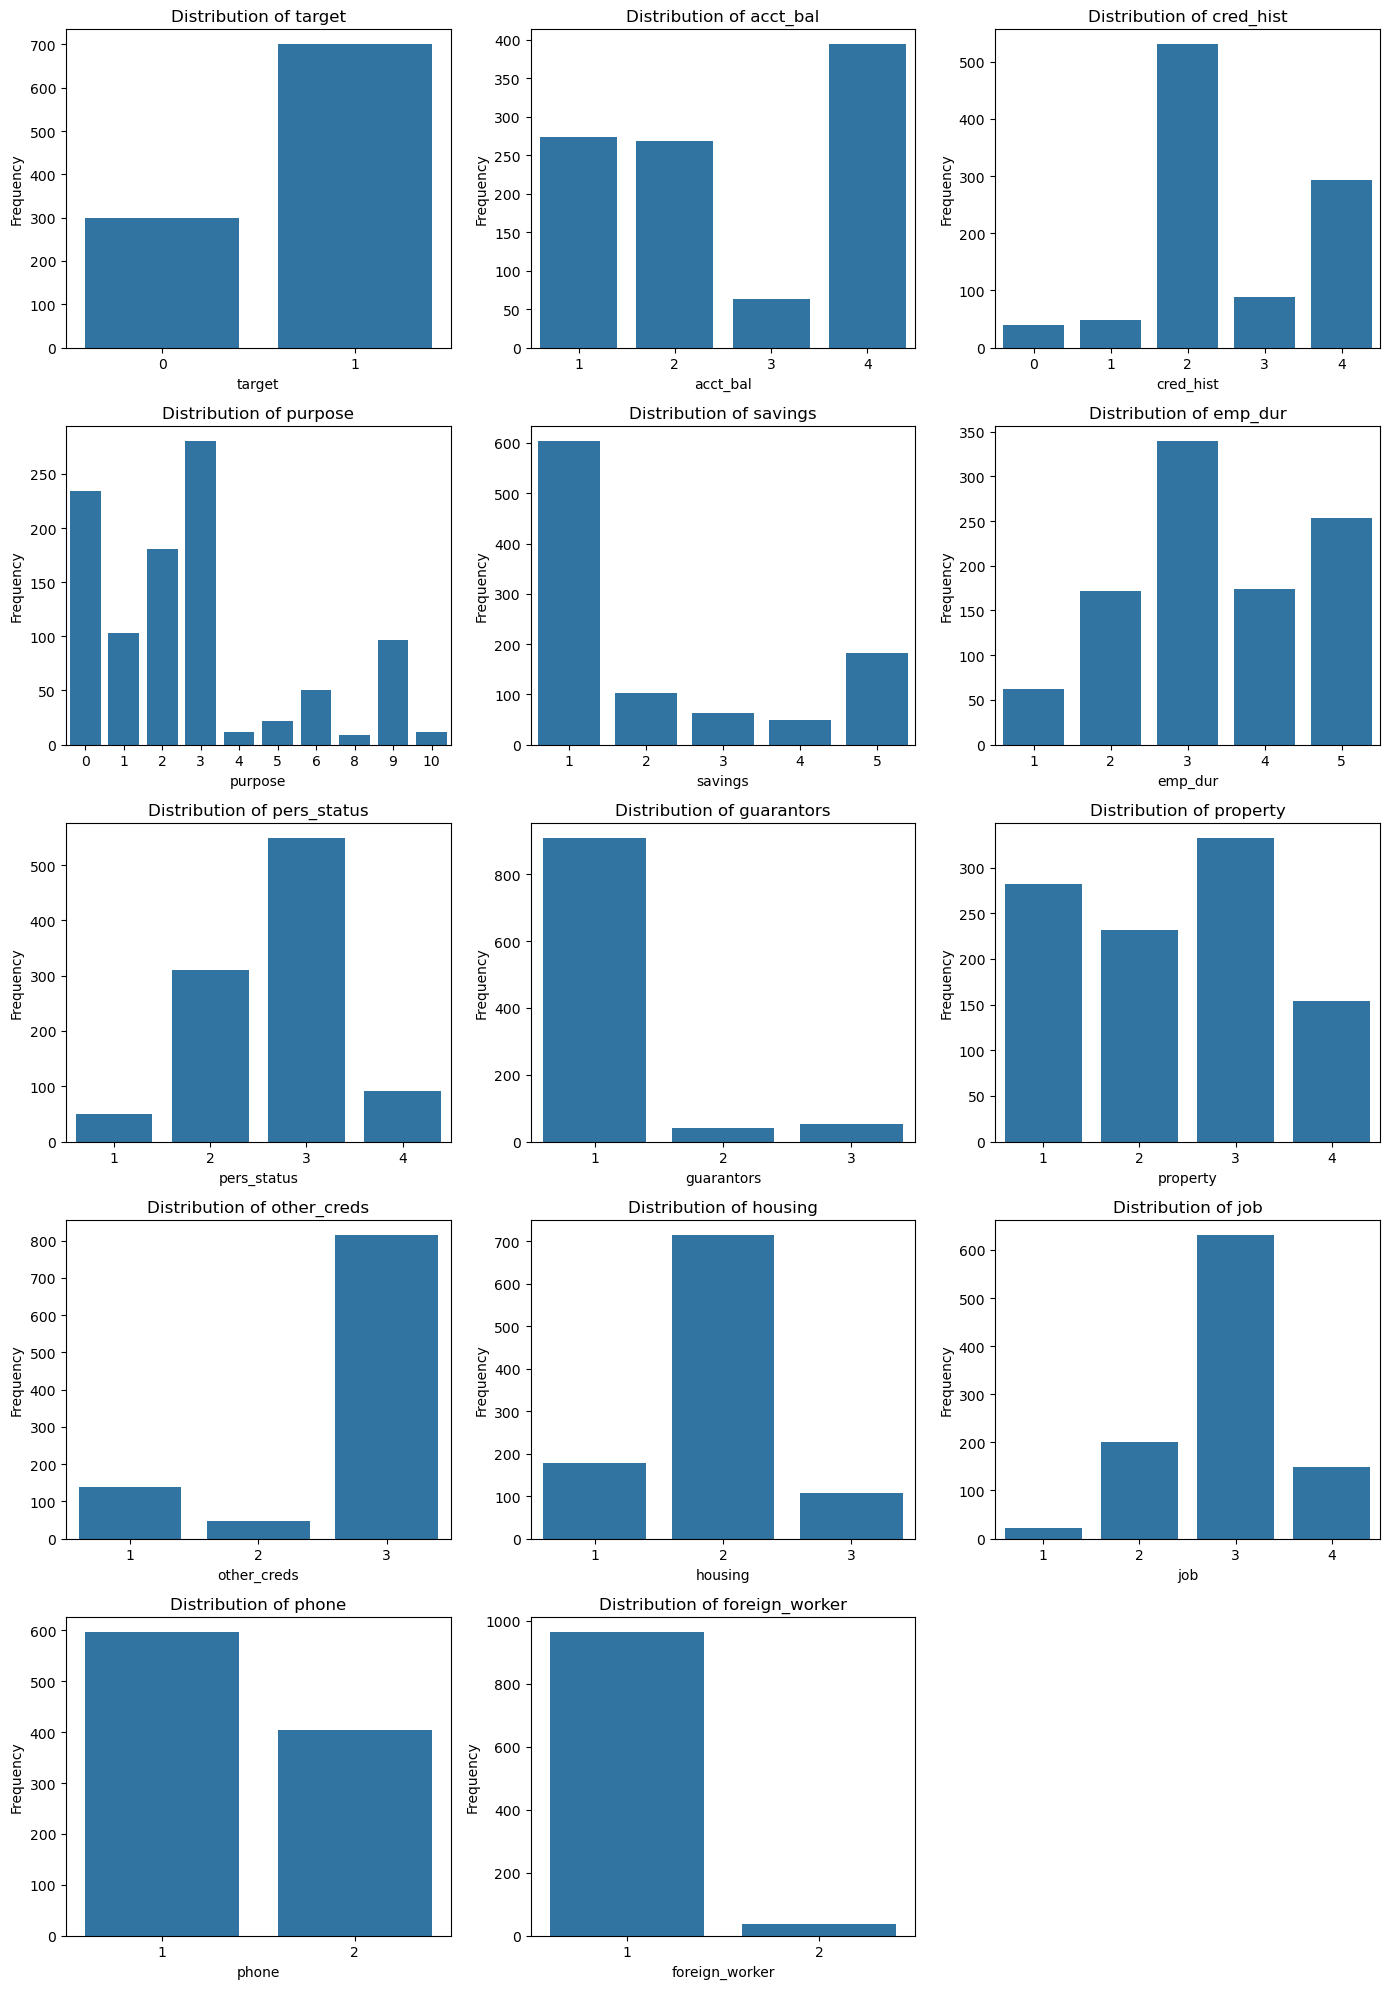

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

for idx, col in enumerate(categorical_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]
    sns.countplot(x=df[col], ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

# Remove empty subplots if any
for idx in range(len(categorical_cols), n_rows * n_cols):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()

DATA SPLIT

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Train shape: {X_train.shape[0]}, Test shape: {X_test.shape[0]}')
print(f'Train target: {y_train.shape[0]}, Test target: {y_test.shape[0]}')

Train shape: 700, Test shape: 300
Train target: 700, Test target: 300


In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 541 to 102
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   acct_bal        700 non-null    category
 1   dur_months      700 non-null    int64   
 2   cred_hist       700 non-null    category
 3   purpose         700 non-null    category
 4   cred_amt        700 non-null    int64   
 5   savings         700 non-null    category
 6   emp_dur         700 non-null    category
 7   pers_status     700 non-null    category
 8   guarantors      700 non-null    category
 9   property        700 non-null    category
 10  age             700 non-null    int64   
 11  other_creds     700 non-null    category
 12  housing         700 non-null    category
 13  job             700 non-null    category
 14  phone           700 non-null    category
 15  foreign_worker  700 non-null    category
dtypes: category(13), int64(3)
memory usage: 31.2 KB


Remover colunas constantes ou com variancia zero antes de normalizar

In [7]:
# Variancia de cada variavel

pd.set_option('display.float_format', '{:.4f}'.format)

variancias = X_train.apply(lambda col: col.astype(float).var())
variancia_df = pd.DataFrame({'variancia': variancias})

print(variancia_df)

                  variancia
acct_bal             1.5847
dur_months         147.3725
cred_hist            1.1607
purpose              7.7478
cred_amt       8009339.9551
savings              2.4869
emp_dur              1.4834
pers_status          0.5084
guarantors           0.2158
property             1.1023
age                124.6097
other_creds          0.4897
housing              0.2767
job                  0.4281
phone                0.2456
foreign_worker       0.0305


In [8]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.9) # limiar de variancia 

X_train_var = pd.DataFrame(
    vt.fit_transform(X_train), # transformar os dados 
    columns=X_train.columns[vt.get_support()], # colunas que passaram no filtro
    index=X_train.index # manter os indices originais
)

NOME DAS VARIAVEIS SELECIONADAS

In [ ]:
['acct_bal', 'dur_months', 'cred_hist','purpose',
'cred_amt', 'savings', 'emp_dur', 'property', 'age']

In [9]:
X_train_var.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 541 to 102
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   acct_bal    700 non-null    int64
 1   dur_months  700 non-null    int64
 2   cred_hist   700 non-null    int64
 3   purpose     700 non-null    int64
 4   cred_amt    700 non-null    int64
 5   savings     700 non-null    int64
 6   emp_dur     700 non-null    int64
 7   property    700 non-null    int64
 8   age         700 non-null    int64
dtypes: int64(9)
memory usage: 54.7 KB


In [10]:
X_train = X_train_var.copy()
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 541 to 102
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   acct_bal    700 non-null    int64
 1   dur_months  700 non-null    int64
 2   cred_hist   700 non-null    int64
 3   purpose     700 non-null    int64
 4   cred_amt    700 non-null    int64
 5   savings     700 non-null    int64
 6   emp_dur     700 non-null    int64
 7   property    700 non-null    int64
 8   age         700 non-null    int64
dtypes: int64(9)
memory usage: 54.7 KB


Obter as mesmas colunas de X_train_var para X_test

In [11]:
# obter as mesmas colunas de X_train_var para X_test
X_test_var = X_test[X_train.columns]
X_test_var.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 521 to 155
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   acct_bal    300 non-null    category
 1   dur_months  300 non-null    int64   
 2   cred_hist   300 non-null    category
 3   purpose     300 non-null    category
 4   cred_amt    300 non-null    int64   
 5   savings     300 non-null    category
 6   emp_dur     300 non-null    category
 7   property    300 non-null    category
 8   age         300 non-null    int64   
dtypes: category(6), int64(3)
memory usage: 11.4 KB


In [12]:
X_test = X_test_var.copy()
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 521 to 155
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   acct_bal    300 non-null    category
 1   dur_months  300 non-null    int64   
 2   cred_hist   300 non-null    category
 3   purpose     300 non-null    category
 4   cred_amt    300 non-null    int64   
 5   savings     300 non-null    category
 6   emp_dur     300 non-null    category
 7   property    300 non-null    category
 8   age         300 non-null    int64   
dtypes: category(6), int64(3)
memory usage: 11.4 KB


PRIMEIRA TENTATIVA DE AJUSTE

In [17]:
# Gerar 1000 amostras bootstrap do X_train (700 linhas, 16 colunas)
#bootstrap_samples = [
#    X_train.sample(n=700, replace=True, random_state=i)
#    for i in range(1000)]
# Cada elemento de bootstrap_samples é um DataFrame amostrado

In [18]:
#from sklearn.linear_model import LogisticRegression

# Gerar 1000 amostras bootstrap de X_train e y_train com reposição
#bootstrap_X = []
#bootstrap_y = []

#for i in range(1000):
#    idx = np.random.choice(X_train.index, size=700, replace=True)
#    bootstrap_X.append(X_train.loc[idx].reset_index(drop=True))
#    bootstrap_y.append(y_train.loc[idx].reset_index(drop=True))

# Treinar 1000 modelos de regressão logística e guardar os coeficientes
#coefs_list = []
#intercepts_list = []

#for Xb, yb in zip(bootstrap_X, bootstrap_y):
#    model = LogisticRegression(max_iter=1000)
#    model.fit(Xb, yb)
#    coefs_list.append(model.coef_[0])
#    intercepts_list.append(model.intercept_[0])

# coefs_list e intercepts_list agora têm os parâmetros de cada modelo treinado

SEGUNDA TENTATIVA AJUSTE

- normalizacao das variaveis preditoras
- agregacao dos dataframes de Y_train ao X_train normalizado para seleção correta da linha no bootstrap
- ajustes nos parametros para melhoria da convergencia

In [13]:
from sklearn.preprocessing import StandardScaler
# 
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), # ajusta e transforma o treino
    columns=X_train.columns,
    index=X_train.index
)

# 
df_train = pd.concat([X_train_scaled, y_train], axis=1)

df_train

,acct_bal,dur_months,cred_hist,purpose,cred_amt,savings,emp_dur,property,age,target
541,-0.4668,2.2003,-0.5095,0.0457,0.2332,1.8520,0.5094,0.5814,0.4900,1
440,1.1232,-0.0254,1.3482,-0.3138,-0.3647,-0.6862,-1.1338,-0.3717,-1.1237,1
482,1.1232,0.2219,0.4193,2.2028,0.1922,-0.6862,-0.3122,1.5345,-0.3168,1
422,-0.4668,-0.4376,1.3482,-1.0328,-0.7583,-0.6862,-1.9555,0.5814,2.9104,1
778,-0.4668,-0.2727,1.3482,0.0457,-0.7335,-0.6862,-0.3122,0.5814,-0.2272,0
...,...,...,...,...,...,...,...,...,...,...
106,1.1232,-0.7673,1.3482,2.2028,-0.6745,-0.6862,-0.3122,-1.3249,-0.5858,1
270,1.1232,-1.2619,-0.5095,-0.6733,-0.7367,0.5829,-0.3122,-0.3717,1.2968,1
860,1.1232,2.2003,-0.5095,2.2028,0.2102,1.8520,-0.3122,-1.3249,0.2210,0
435,1.1232,-1.1795,0.4193,0.0457,-0.8746,1.8520,1.3310,1.5345,0.0417,1


In [14]:
# Transformação do conjunto de teste
# Usa o mesmo scaler já ajustado (sem refazer o fit)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),   # aplica transformação com média e desvio do treino
    columns=X_test.columns,
    index=X_test.index
)

### Explicação formal transformacao X_test

**fit_transform(X_train)**

    - Calcula media e desvio padrao apenas do treino.

    - Salva esses valores internamente em scaler.mean_ e scaler.scale_.

    - Aplica a padronizacao no proprio X_train.

**- transform(X_test)**
    - Usa as mesmas estatisticas (mean_ e scale_) aprendidas no treino.

    - Padroniza o teste mantendo consistencia com o espaço aprendido.

    - Nenhuma estatistica do X_test eh usada — portanto nao ha data leakage.

CHECK

In [15]:
print("Médias usadas no scaler:", scaler.mean_)
print("Desvios padrão usados no scaler:", scaler.scale_)

Médias usadas no scaler: [2.58714286e+00 2.13085714e+01 2.54857143e+00 2.87285714e+00
 3.31940429e+03 2.08142857e+00 3.38000000e+00 2.39000000e+00
 3.55342857e+01]
Desvios padrão usados no scaler: [1.25793725e+00 1.21310316e+01 1.07660085e+00 2.78149094e+00
 2.82805552e+03 1.57587099e+00 1.21709255e+00 1.04916974e+00
 1.11548950e+01]


In [16]:
print(X_test_scaled.describe().T)

              count    mean    std     min     25%     50%    75%    max
acct_bal   300.0000 -0.0269 0.9990 -1.2617 -1.2617 -0.4668 1.1232 1.1232
dur_months 300.0000 -0.1114 0.9755 -1.4268 -0.7673 -0.2727 0.2219 3.1895
cred_hist  300.0000 -0.0111 1.0200 -2.3672 -0.5095 -0.5095 1.3482 1.3482
purpose    300.0000 -0.0538 0.9537 -1.0328 -0.7632 -0.3138 0.0457 2.5623
cred_amt   300.0000 -0.0568 0.9926 -1.0853 -0.6835 -0.3605 0.1555 4.3679
savings    300.0000  0.0499 1.0079 -0.6862 -0.6862 -0.6862 0.5829 1.8520
emp_dur    300.0000  0.0110 0.9756 -1.9555 -0.3122 -0.3122 0.5094 1.3310
property   300.0000 -0.1017 0.9997 -1.3249 -1.3249 -0.3717 0.5814 1.5345
age        300.0000  0.0023 1.0581 -1.4822 -0.8547 -0.2272 0.4900 3.4483


### Export CSV Final DATA SET

In [17]:
# Export CSV Final DATA SET
df_train.to_csv('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/df_train_final.csv', index=False)

In [21]:
# export X_test e y_test to csv
X_test_scaled.to_csv('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/X_test_scaled.csv', index=False)
y_test.to_csv('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/y_test.csv', index=False)

TRAINING LOGISTIC REGRESSION MODEL - USING LASSO REGULARIZATION

In [ ]:
from sklearn.linear_model import LogisticRegression

# 
bootstrap_dfs = [
    df_train.sample(n=700, replace=True, random_state=i).reset_index(drop=True)
    for i in range(1000)
]

# 4. 
coefs_list = []
intercepts_list = []

for df_boot in bootstrap_dfs:
    Xb = df_boot.drop('target', axis=1)
    yb = df_boot['target']
    model = LogisticRegression(
        penalty='l2',        # Ridge regularization
        solver='lbfgs',      # Bom para penalty l2
        max_iter=5000,       # Aumenta para melhorar convergência
        C=1.0,               # Regularização padrão
        random_state=42
    )
    model.fit(Xb, yb)
    coefs_list.append(model.coef_[0])
    intercepts_list.append(model.intercept_[0])

#

/Users/mpa/miniforge3/envs/ds_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mpa/miniforge3/envs/ds_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mpa/miniforge3/envs/ds_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mpa/miniforge3/envs/ds_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mpa/miniforge3/envs/ds_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X

In [19]:
coefs_list[0]

array([ 0.63085681, -0.45185993,  0.44718182,  0.0762784 ,  0.05979917,
        0.5117364 ,  0.16847187, -0.25684138,  0.3883186 ])

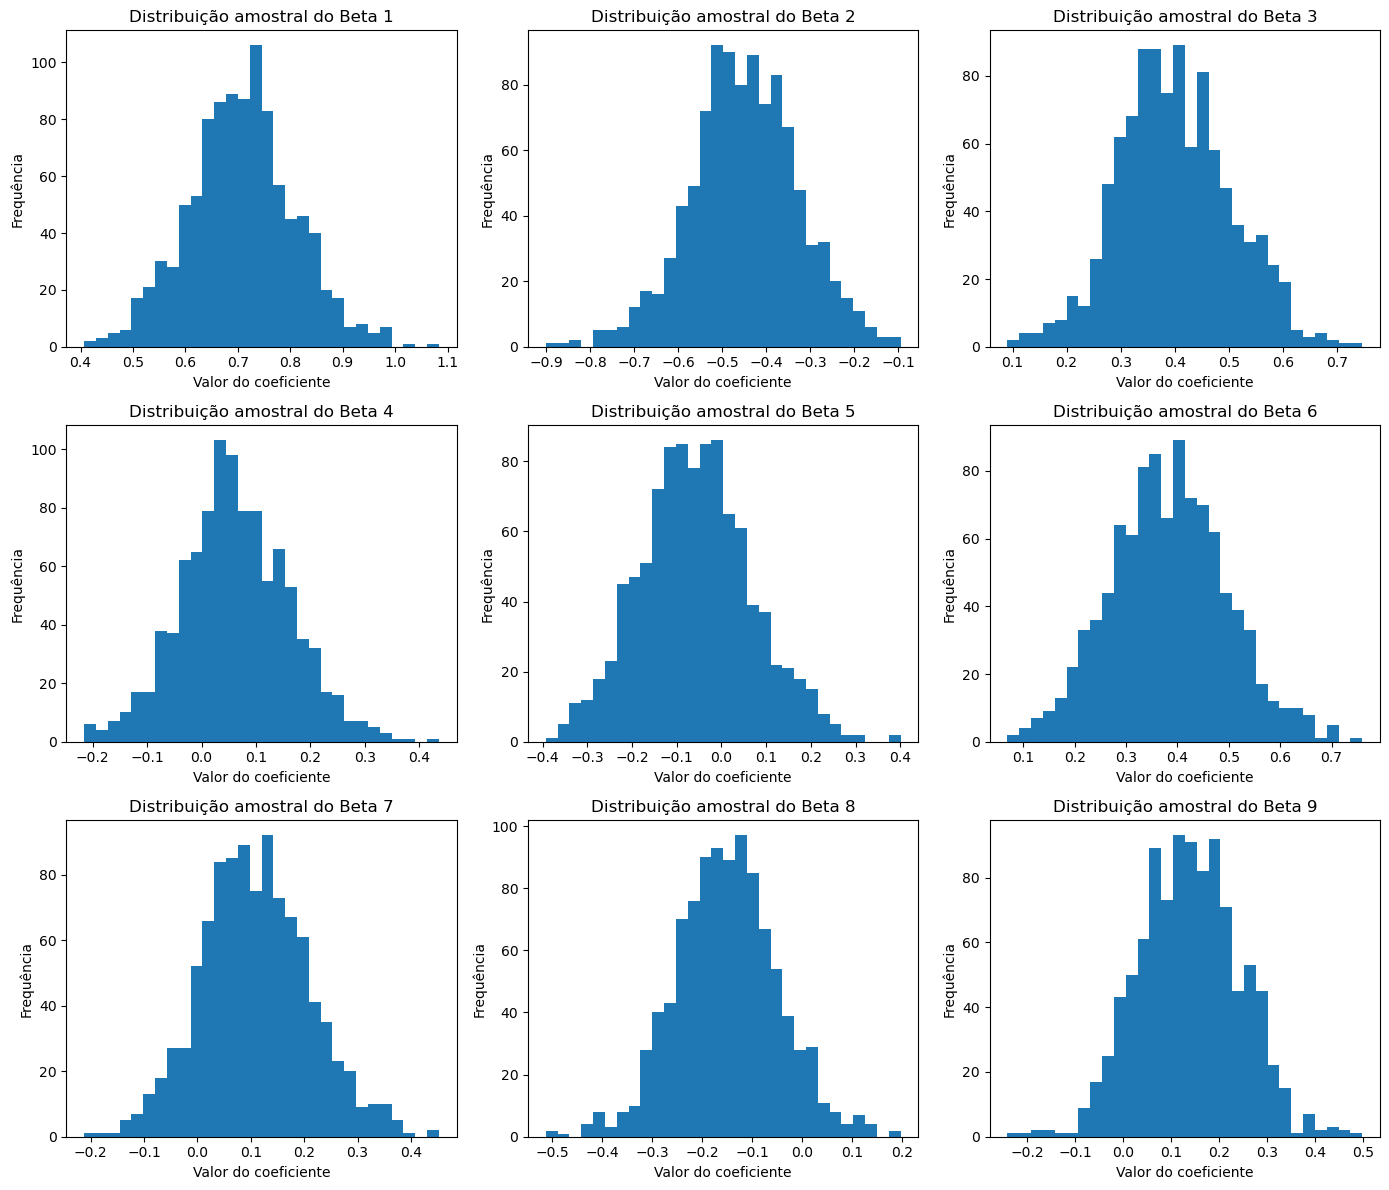

In [20]:
import matplotlib.pyplot as plt
import numpy as np

num_coefs = len(coefs_list[0])  # Número de coeficientes por modelo
n_cols = 3
n_rows = int(np.ceil(num_coefs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

for i in range(num_coefs):
    coef_amostral = [coef[i] for coef in coefs_list]
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    ax.hist(coef_amostral, bins=30)
    ax.set_title(f'Distribuição amostral do Beta {i+1}')
    ax.set_xlabel('Valor do coeficiente')
    ax.set_ylabel('Frequência')

# Remove subplots vazios, se houver
for j in range(num_coefs, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()